<a href="https://colab.research.google.com/github/MRazaRashid/zero_to_deep_learning_video/blob/master/GradientDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('wines.csv')

In [ ]:
df.sample(8)

,Class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280-OD315_of_diluted_wines,Proline
75,2,11.66,1.88,1.92,16.0,97,1.61,1.57,0.34,1.15,3.80,1.23,2.14,428
56,1,14.22,1.70,2.30,16.3,118,3.20,3.00,0.26,2.03,6.38,0.94,3.31,970
8,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
151,3,12.79,2.67,2.48,22.0,112,1.48,1.36,0.24,1.26,10.80,0.48,1.47,480
155,3,13.17,5.19,2.32,22.0,93,1.74,0.63,0.61,1.55,7.90,0.60,1.48,725
159,3,13.48,1.67,2.64,22.5,89,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620
162,3,12.85,3.27,2.58,22.0,106,1.65,0.60,0.60,0.96,5.58,0.87,2.11,570
150,3,13.50,3.12,2.62,24.0,123,1.40,1.57,0.22,1.25,8.60,0.59,1.30,500


In [ ]:
y = df['Class']

In [ ]:
y.value_counts()

,count
Class,
2,71
1,59
3,48


In [ ]:
y_cat = pd.get_dummies(y)

In [ ]:
y_cat.head()

,1,2,3
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [ ]:
X = df.drop('Class', axis=1)

In [ ]:
X.shape

(178, 13)

In [ ]:
sns.pairplot(df, hue='Class')

The pair plot shows the relationships between the different chemical features of the wine dataset, with the observations separated into three classes. Several features show positive relationships, particularly Flavanoids, Total Phenols, Proanthocyanins and OD280/OD315. The distributions and scatterplots also show that some features provide better separation between the three classes than others. Features such as Flavanoids, Proline, Alcohol and OD280/OD315 show noticeable differences between classes, suggesting that they may be useful predictors for classification. However, some feature combinations show considerable overlap between classes, indicating that a combination of multiple features is likely to be more effective than relying on a single feature.

In very simple terms

Think of the whole graph as asking:

"Which characteristics of wine are related to each other, and which characteristics can help me tell Class 1, Class 2 and Class 3 wines apart?"

The diagonal = individual feature distributions.

The other squares = relationships between two features.

The colours = wine classes.

Separated colours = good class discrimination.

Overlapping colours = harder to distinguish.

In [ ]:
sc = StandardScaler()

In [ ]:
Xsc = sc.fit_transform(X)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, Adadelta, RMSprop
import tensorflow.keras.backend as K

In [ ]:
K.clear_session()
model = Sequential()
model.add(Dense(5, input_shape=(13,),
                kernel_initializer='he_normal',
                activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(RMSprop(learning_rate=0.1),
              'categorical_crossentropy',
              metrics=['accuracy'])

model.fit(Xsc, y_cat.values,
          batch_size=8,
          epochs=10,
          verbose=1,
          validation_split=0.2)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8451 - loss: 0.3535 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9648 - loss: 0.1346 - val_accuracy: 0.9167 - val_loss: 0.2370
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9718 - loss: 0.0447 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9930 - loss: 0.0154 - val_accuracy: 0.9722 - val_loss: 0.0487
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9718 - loss: 0.0645 - val_accuracy: 0.9722 - val_loss: 0.1039
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9859 - loss: 0.0413 - val_accuracy: 1.0000 - val_loss: 0.0161
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9722 - val_loss: 0.0213
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 2.9572e-04 - val_accuracy: 0.9722 - val_

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178 (716.00 B)

 Trainable params: 88 (352.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 90 (364.00 B)

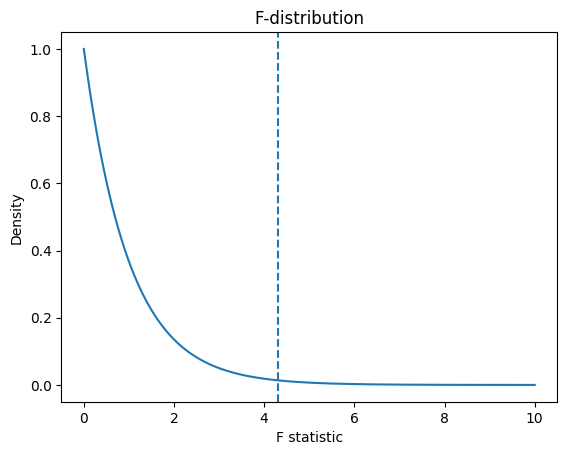

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Degrees of freedom
df1 = 2
df2 = 1098

# F values
x = np.linspace(0, 10, 1000)

# Probability density
y = f.pdf(x, df1, df2)
F_stat=4.3
# Plot
plt.plot(x, y)
plt.axvline(F_stat, linestyle="--")
plt.xlabel("F statistic")
plt.ylabel("Density")
plt.title("F-distribution")
plt.show()

In [1]:
p_value = f.sf(F_stat, df1, df2)

print(p_value)

NameError: name 'f' is not defined